In [60]:
import sys, os, time, string, math, subprocess
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import scipy.interpolate as interpol
from astropy import constants as const
from astropy import units as u
import pandas as pd
from pagn import Sirko

In [61]:
#cgs units
Msun=const.M_sun.cgs #kg per solar mass
Rsun=const.R_sun.cgs #meters per solar radius
G=const.G.cgs
c=const.c.cgs
sigma_SB=const.sigma_sb.cgs #stefan-boltzmann const
yr=3.15e7 #seconds per year
h=const.h.cgs #planck const
k_B=const.k_B.cgs #boltzmann const
m_p=const.m_p.cgs #mass of proton/hydrogen atom
sigma_T=const.sigma_T.cgs #Thomson xsec
PI=np.pi

In [62]:
def compute_B_lambda(wavelength, temperature):
    temperature = temperature * u.K
    wavelength = wavelength * u.AA
    #wavelength = wavelength.to('cm')

    x = (h * c / (wavelength * k_B * temperature)).decompose().value
    B_lambda = (2 * h * c**2 / wavelength**5) / (np.exp(x) - 1)

    return B_lambda.to(u.erg / (u.cm**2 * u.s * u.Angstrom))

def v_kep(M, r):
    #compute keplerian velocity given M, r
    #Inputs:M, r in SI
    #outputs: v in SI
    v=np.sqrt(G*M/r)

    return v

def find_spotTemp(epsilon, M_SMBH, dotm_edd, radius, r_in, r_g_bin, r_g_SMBH, model, r_alt, f_dep, M_bin, deltaM, deltaR_Hill, spot_radius, R_Hill):
    #Spot temp varies as r from binary/merger due to orbital change
    #from evil supervillain mass loss
    #3 zones:
    # a) inner most zone is shocked, temp varies with r
    # b) middle zone (w/ most of mass) expands subsonically, ~constant T
    # c) outer zone is mass lost from RHill to SMBH Kep flow, subsonic, ~const T
    #inputs:
    #spot_radius in SI
    #R_Hill in SI
    #M_bin, M_SMBH, deltaM in Msun
    
    #radius in r_g_SMBH
    #r_g_bin=(G*M_bin*Msun)/c**2
    #r_g_SMBH=(G*M_SMBH*Msun)/c**2

    #get sound speed (SI)
    c_s=soundspeed(radius, model)
    #first compute Mach number--need spot_radius in r_g_bin
    Mach=0.5/np.sqrt(spot_radius/r_g_bin)*(c/c_s)*(deltaM/M_bin)
    #and spot radius at which Mach number=1.0 (in r_g_bin)--for deltavee2
    spot_rad_Mach1=0.25*(c/c_s)**2*(deltaM/M_bin)**2
    #and local disk temp in absence of binary
    Tdisk=find_Temp(epsilon,M_SMBH,dotm_edd,radius,r_in,model,r_alt,f_dep)
    #compute velocity change from Mach 1 region to exterior of spot (deltavee2)
    deltavee2=v_kep((M_bin*Msun),(spot_rad_Mach1*r_g_bin))-v_kep((M_bin*Msun),R_Hill)
    #compute velocity change from material that leaves R_Hill for disk flow
    deltavee3=v_kep((M_SMBH*Msun),(radius*r_g_SMBH))-v_kep((M_SMBH*Msun),((radius*r_g_SMBH)-R_Hill))

    #compute change of R_Hill--for some a, zone 3 is too thin to count
    #(unless subdivide spot into even smaller annuli)

    if ((Mach>=1.0) and (spot_radius<(R_Hill-deltaR_Hill))):
        #if supersonic and not in zone 3 (the lost section of the Hill sphere)
        T=(5.0/16.0)*Mach**2*Tdisk
    elif ((Mach<1.0) and (spot_radius<(R_Hill-deltaR_Hill))):
        #if subsonic and not in zone 3
        T=(1.0/3.0)*(m_p/k_B)*((deltaM/M_bin)*deltavee2)**2
    elif (spot_radius>=(R_Hill-deltaR_Hill)):
        #if in zone 3 (lost sec of Hill sphere)
        T=(1.0/3.0)*(m_p/k_B)*deltavee3**2
        print(T)
    
    return T

def soundspeed(radius, model):
    #eventually we should make this a real function of AGN disk radius
    #output in SI
    #TQM mostly=10km/s, SG ~ 56km/s

    if (model=='SG'):
        cs=56000.0
    elif (model=='TQM'):
        cs=10000.0
    
    return cs
    
def find_Temp(epsilon,M_SMBH,dotm_edd,radius,r_in,model,r_alt,f_dep):
    #find temp as a fn of radius
    #
    #Options:
    #Sirko & Goodman 2003 (SG): T_SG
    #Zero torque at ISCO (ZT): T_ZT  *****DEFAULT
    #Non-zero torque at ISCO (NZT): T_NZT
    #Temperature suppression inside r_alt such that flux is down (from ZT) by factor f_dep (SUP): T_SUP
    #
    #Sirko & Goodman 2003 is similar to non-zero torque at the ISCO
    #---but differs by factor to approximate spectral hardening
    #assume sigma_SB T^4=(3/8pi) dotM Omega^2
    #use Omega=sqrt(GM/r^3); put r in units r_g; dotM in units dotM_edd
    prefactor=((3.0/2.0)*(c**5)*m_p/(epsilon*G*M_SMBH*Msun*sigma_T*sigma_SB)) ** 0.25
    T_SG=prefactor*(dotm_edd**0.25)*(radius**-0.75)
    
    #Non-zero-torque at ISCO temp profile:
    #include factor f, O(1), which approximates spectral hardening from pure BB
    #set f=2
    #prefactor is otherwise identical to SG
    #See e.g. Gammie 1999; Krolik & Agol 2000; Narayan et al. 1997; Ashfordi & Paczynski 2003
    f=2.0
    T_NZT=f*T_SG
    
    #Zero torque at the ISCO temp profile:
    #see e.g. Zimmerman et al. 2005
    #To implement:
    if (radius >= r_in):
        T_ZT=T_NZT*((1.0-((radius/r_in)**-0.5))**0.25)
    else:
        T_ZT=0.0

    #Messing with the temperature profile for semi-physical reasons:
    #Rather than arbitrarily suppressing the flux by factor f_depress,
    #change actual temp of 'suppressed' region
    if (radius >= r_alt):
        T_SUP=T_ZT
    else:
        T_SUP=T_ZT*(f_dep**0.25)

    if (model=='SG'):
        T=T_SG
    elif (model=='ZT'):
        T=T_ZT
    elif (model=='NZT'):
        T=T_NZT
    elif (model=='SUP'):
        T=T_SUP
    else:
        print('WARNING: temperature profile model not recognized, using zero-torque model')
        T=T_ZT
        
    return T

def find_area(r1,r2,r_g):
    #find area of annulus
    #2pi R deltaR
    R1 = r1 * r_g
    R2 = r2 * r_g
    return math.pi * (R2**2 - R1**2)

def get_filter_profile(path, filename):
    #assumes file contains ONLY wavelength and flux, in appropriate units, no headers, etc.
    
    #open the file for reading
    file1 = open(path+filename, 'r')

    #read in the data line by line, split into float lists of wavelength and transmission fraction
    lam1list=[]
    trans1list=[]
    for line in file1:
        line=line.strip()
        columns=line.split()
        lam1list.append(float(columns[0]))
        trans1list.append(float(columns[1]))

    #close file
    file1.close()

    #re-cast as arrays (from lists) for manipulation
    lam1 = np.array(lam1list)
    trans1 = np.array(trans1list)

    return lam1, trans1

def get_spotTeff(spot_temp, log_tau):
    #use very basic propagation formula from SG03 (eqn 4), given T_mid, tau

    #unlog
    tau=10.0**log_tau
    thing=(3.0*tau/8.0)+0.5+(1.0/(4.0*tau))
    Teff=spot_temp*(thing**-0.25)
    
    return Teff

def si_from_r_g(smbh_mass, distance_rg):
    """Calculate the SI distance from r_g

    Parameters
    ----------
    smbh_mass : float
        Mass [M_sun] of the SMBH
    distance_rg : array_like
        Distances [r_{g,SMBH}]

    Returns
    -------
    distance : numpy.ndarray
        Distance in SI with :obj:`astropy.units.quantity.Quantity` type
    """
    # Calculate c and G in SI
    c = const.c.to('m/s')
    G = const.G.to('m^3/(kg s^2)')
    # Assign units to smbh mass
    if hasattr(smbh_mass, 'unit'):
        smbh_mass = smbh_mass.to('solMass')
    else:
        smbh_mass = smbh_mass * u.solMass
    # convert smbh mass to kg
    smbh_mass = smbh_mass.to('kg')
    # Calculate r_g in SI
    r_g = G*smbh_mass/(c ** 2)
    # Calculate distance
    distance = (distance_rg * r_g).to("m")

    assert np.isfinite(distance).all(), \
        "Finite check failure: distance"
    assert np.all(distance > 0).all(), \
        "distance contains values <= 0"

    return distance

In [63]:
disk_model = Sirko.SirkoAGN()
disk_model.solve_disk(N=1e4)
# dont forget all pagn stuff is in mks units
optical_depth = disk_model.tauV
density = disk_model.rho
radius = disk_model.R
height = disk_model.h
kappa = disk_model.kappa
teff = disk_model.Teff4**0.25
sound_speed = disk_model.cs

L_agn = (0.1 * 1.26) * 10**38 * (10**8 / 1) * u.erg / u.s#(disk_model.L_Edd() * u.watt).to(u.erg / u.s)
print(L_agn)

### Sirko & Goodman 2003 parameters ###
Mbh = 1.000000e+08 MSun
Mdot = 1.298344e+00 MSun/yr
le = 0.5
Rs = 9.570121e-06 pc
Rmin = 2.500000e+00 Rs
Rmax = 1.000000e+07 Rs, 9.570121e+01 pc
alpha = 0.01
b = 0
eps = 0.1
X = 0.7
Opacity = combined

debug = False
xtol = 1e-10
root method = lm
Q<1 at i=3408 (R=7.92e+02 Rs)
Beginning star formation at index 3408
Mdisk = 335459537.4383986 Msun
Mdisk/Mbh = 3.354595374383986
1.26e+45 erg / s


In [64]:
file_path = "/Users/vprit/desktop/work/mcfacts/em_jets/output_mergers_population.dat"
pagn_sg_disk = pd.DataFrame({'radius': radius,
                   'density': density,
                   'tau': optical_depth,
                   'height': height,
                   'kappa': kappa,
                   'cs': sound_speed})

output_mergers_population = pd.read_csv(file_path, names = ['gal','radius_rg', 'mass_final', 'chi_eff', 'spin_final', 'spin_angle_final', 'mass_1', 'mass_2', 
                 'spin_1', 'spin_2', 'spin_angle_1', 'spin_angle_2', 'gen_1', 'gen_2', 'time_merged', 'chi_p', 
                 'v_kick', 'lum_shock', 'lum_jet'], sep=" ", comment="#", index_col=False)
output_mergers_population = output_mergers_population.head(10)

radius_rg = output_mergers_population['radius_rg'].values
output_mergers_population['radius'] = np.array(si_from_r_g(1e8, radius_rg))
output_mergers_population = output_mergers_population.sort_values('radius')
output_mergers_population = pd.merge_asof(output_mergers_population, pagn_sg_disk, on='radius', suffixes = (None, '_pagn'))
output_mergers_population = output_mergers_population.sort_values('gal')
output_mergers_population
output_mergers_population['radius'] = output_mergers_population['radius'] * 100
output_mergers_population['density'] = output_mergers_population['density'] * 0.001
output_mergers_population['cs'] = output_mergers_population['cs'] * 100


/var/folders/pw/nc5rj5md667b29kntncq7jbw0000gn/T/ipykernel_34259/2231882417.py:9: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  output_mergers_population = pd.read_csv(file_path, names = ['gal','radius_rg', 'mass_final', 'chi_eff', 'spin_final', 'spin_angle_final', 'mass_1', 'mass_2',


In [65]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_g.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_g = disk_F_lam_tot.value * 1e-10 
print(len(filterlam[0]))
print(len(disk_F_lam_tot))
print(SED_g)


1806
1806
[7.70776230e+29 7.70319664e+29 7.69863482e+29 ... 3.19358772e+29
 3.19228648e+29 3.19098600e+29]


In [66]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_i.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_i = disk_F_lam_tot.value * 1e-10 
print(len(filtertrans[0]))
print(len(disk_F_lam_tot))
print(SED_i)


1570
1570
[2.12391077e+29 2.12318343e+29 2.12245645e+29 ... 1.30990212e+29
 1.30953714e+29 1.30917230e+29]


In [67]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_r.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_r = disk_F_lam_tot.value * 1e-10 
print(len(filtertrans[0]))
print(len(disk_F_lam_tot))
print(SED_r)


1690
1690
[3.61620248e+29 3.61464902e+29 3.61309651e+29 ... 1.92258607e+29
 1.92195505e+29 1.92132433e+29]


In [68]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_u.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_u = disk_F_lam_tot.value * 1e-10 
print(len(filtertrans[0]))
print(len(disk_F_lam_tot))
print(SED_u)


886
886
[1.18534348e+30 1.18450132e+30 1.18366000e+30 1.18281954e+30
 1.18197993e+30 1.18114116e+30 1.18030324e+30 1.17946616e+30
 1.17862993e+30 1.17779454e+30 1.17695999e+30 1.17612628e+30
 1.17529341e+30 1.17446138e+30 1.17363019e+30 1.17279983e+30
 1.17197031e+30 1.17114162e+30 1.17031376e+30 1.16948674e+30
 1.16866055e+30 1.16783518e+30 1.16701065e+30 1.16618694e+30
 1.16536406e+30 1.16454201e+30 1.16372078e+30 1.16290037e+30
 1.16208078e+30 1.16126202e+30 1.16044407e+30 1.15962695e+30
 1.15881064e+30 1.15799515e+30 1.15718047e+30 1.15636661e+30
 1.15555357e+30 1.15474133e+30 1.15392991e+30 1.15311930e+30
 1.15230950e+30 1.15150050e+30 1.15069232e+30 1.14988493e+30
 1.14907836e+30 1.14827259e+30 1.14746762e+30 1.14666345e+30
 1.14586009e+30 1.14505753e+30 1.14425576e+30 1.14345479e+30
 1.14265462e+30 1.14185525e+30 1.14105667e+30 1.14025888e+30
 1.13946189e+30 1.13866569e+30 1.13787028e+30 1.13707566e+30
 1.13628183e+30 1.13548879e+30 1.13469653e+30 1.13390506e+30
 1.13311437e+30 

In [69]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_y.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_y = disk_F_lam_tot.value * 1e-10 
print(len(filter_filenames))
print(len(filtertrans[0]))
print(len(disk_F_lam_tot))
print(SED_y)


1
1906
1906
[1.07031788e+29 1.07004430e+29 1.06977083e+29 ... 6.87951011e+28
 6.87805437e+28 6.87659908e+28]


In [70]:

from astropy import units as u

M_SMBH = 1E8
dotm_edd = 0.1
radius_in = 6.0
radius_out = 50000
epsilon = 0.1

spot_radius_in = 6.0 # in units of r_g_bin
event_rad = output_mergers_population['radius_rg'].to_numpy()#np.linspace(radius_in, radius_out, 5) # grab
log_tau = np.log10(output_mergers_population['tau']).to_numpy() #np.linspace(4, 6, len(event_rad)) # grab


# note: this will need to change bc delta M should be related to mfinal
M_bin = output_mergers_population['mass_final'].to_numpy()#np.random.uniform(10, 100, 5) # grab + mass 1 and 2
#deltaM = 0.05 * M_bin

r_alt=0.0
f_depress=1.0
tempmod='SG'

r_g_SMBH=G*M_SMBH*Msun/c**2
r_g_bin=G*M_bin*Msun/c**2
R_Hill = event_rad*r_g_SMBH*pow(M_bin/(3.0*M_SMBH),1.0/3.0)

#divvy up disk radii
log_radius=np.arange(np.log10(radius_in),np.log10(radius_out),0.01)
radius=10**log_radius

path='/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/'
filter_filenames=['LSST_z.dat']
filterlam=[]
filtertrans=[]
for i in range(len(filter_filenames)):
    fn=filter_filenames[i]
    profilelam, profiletrans=get_filter_profile(path, fn)
    #convert wavelengths from Angstroms to m
    profilelam=(profilelam) #*1.0e-10
    filterlam.append(profilelam)
    filtertrans.append(profiletrans)
    
disk_phot=np.zeros(len(filter_filenames))
spot_phot=np.zeros((len(event_rad),len(filter_filenames)))
spot_to_disk_fluxratio=np.zeros((len(event_rad),len(filter_filenames)))

columns = filter_filenames
df = pd.DataFrame(columns=columns)
for j in range(len(filter_filenames)):
    #initialize final disk array
    disk_F_lam_tot=np.zeros(len(filterlam[j]))
    for i in range((len(radius)-1)):
        disk_temp=find_Temp(epsilon,M_SMBH,dotm_edd,radius[i],radius_in, tempmod, r_alt, f_depress)
        disk_B_lambda=compute_B_lambda(filterlam[j], disk_temp)
        disk_area=find_area(radius[i],radius[i+1],r_g_SMBH)
        #flux=A*B_lambda per annulus
        disk_F_lam_ann=disk_area*disk_B_lambda
        
        disk_F_lam_tot=disk_F_lam_ann + disk_F_lam_tot
        
    #multiply SED by transmission profile and sum
    disk_phot[j]=sum(disk_F_lam_tot.value*filtertrans[j])
# Add the computed values as a new row in the DataFrame
df.loc[0] = disk_phot
df

disk_F_lam_tot
SED_z = disk_F_lam_tot.value * 1e-10 
print(len(filtertrans[0]))
print(len(disk_F_lam_tot))
print(SED_z)


1356
1356
[1.42507055e+29 1.42465893e+29 1.42424748e+29 ... 9.92764783e+28
 9.92519055e+28 9.92273413e+28]


In [71]:
print(SED_g.shape, SED_i.shape, SED_r.shape, SED_u.shape, SED_y.shape, SED_z.shape)
total_SED  = np.concatenate((SED_g, SED_i, SED_r, SED_u, SED_y, SED_z))
sorted_SED = np.sort(total_SED)
print(total_SED.shape)
print(sorted_SED.shape)


(1806,) (1570,) (1690,) (886,) (1906,) (1356,)
(9214,)
(9214,)


In [72]:


def read_filter(path):
    """Reads a 2-column LSST filter file using NumPy."""
    return np.loadtxt(path)

# Reading and convering the LSST filter data
g = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_g.dat')
# green filter from 3865-5669
i = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_i.dat')
#red filter from 5371-7059
r = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_r.dat')
# infrared filter from 6761-8329
u = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_u.dat')
# ultraviolet filter from 3201-4085
y = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_y.dat')
# y filter from 9085-10989
z = read_filter('/Users/vprit/McFACTS/src/mcfacts/inputs/data/LSST_filters/LSST_z.dat')
# z filter from 8031-9385

r_filter, r_eff = r[:,0], r[:,1] # 0 for wavelength 1 for transmission
g_filter, g_eff = g[:,0], g[:,1]
i_filter, i_eff = i[:,0], i[:,1]
u_filter, u_eff = u[:,0], u[:,1]
y_filter, y_eff = y[:,0], y[:,1]
z_filter, z_eff = z[:,0], z[:,1]

r_wave = r_filter * 1e-10 # I think its in angstroms  
g_wave = g_filter * 1e-10
i_wave = i_filter * 1e-10
u_wave = u_filter * 1e-10
y_wave = y_filter * 1e-10
z_wave = z_filter * 1e-10

# converting wavelength to frequency
r_freq = c/r_wave #using c already below as 3e8
g_freq = c/g_wave
i_freq = c/i_wave
u_freq = c/u_wave
y_freq = c/y_wave
z_freq = c/z_wave

total_freq = np.concatenate((r_freq, g_freq, i_freq, u_freq, y_freq, z_freq))#sorting the frequency values
sorted_freq = np.sort(total_freq)
total_wavelength = np.concatenate((r_wave, g_wave, i_wave, u_wave, y_wave, z_wave))
sorted_wavelength = np.sort(total_wavelength)
print(sorted_wavelength.shape)

(9214,)


temp =  22280.623057283337 with a vel of 18091.99206062451 density of 2.7066864292176647e-06 lum of 7.11e43
b_fs * gamma_fs =  6.034838962035464e-07


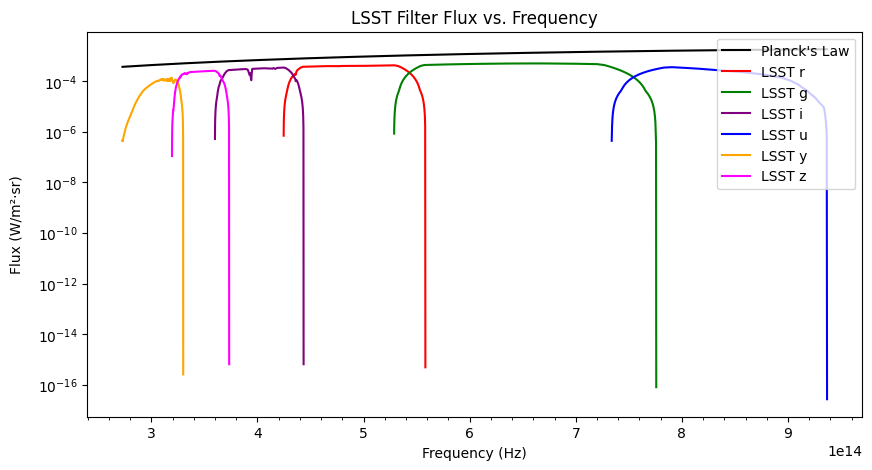

In [78]:
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.constants import h, c, k_B, m_p, R_sun, au
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parameters that you can change for new model
v_fs = 18091.99206062451 #velocity of forward shock in cm/s
dens = 2.7066864292176647e-06 #density of agn disk

# Constants used 
#t = 5800 #Temp of sun for now can change for what we are looking at 
rad = R_sun #Radius of sun in meters for now will change to bh later
d = au #distance from earth to sun in meters change later to distance to agn
h = h.cgs.value #Planck constant
c = c.cgs.value #speed of light
k = k_B.cgs.value #Boltzmann constant
m_p = m_p.cgs.value #proton mass
pi = np.pi #Pi constant

# Function to calculate temperature based on velocity of forward shock and density
def temp_fxn(v_fs, dens, m_p, c, k):
    """
    Calculate the temperature t based on velocity of forward shock and other physical parameters. All parameters should be in CGS units

    Parameters
    ----------
    v_fs : float
        Velocity of the forward shock in m/s.
    dens : float
        Density of AGN disk.
    m_p : float
        Proton mass.
    c : float
        Speed of light.
    k : float
        Boltzmann constant.

    Returns
    -------
    t : float
        Calculated temperature.
    """
    b_fs = v_fs / c
    gamma_fs = 1 / np.sqrt(1 - b_fs**2)
    gamma_fs_f = gamma_fs**(1 + np.sqrt(3))
    gamma_sf = gamma_fs / np.sqrt(2)
    gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
    n = dens / m_p

    if b_fs * gamma_fs <= 0.03:
        t = 1e4 * ((b_fs / 0.02)**0.5) * ((dens / 1e-16)**0.25)
    elif b_fs * gamma_fs > 0.03 and b_fs * gamma_fs <= 1:
        t = (10**(0.975 + (1.735 * ((b_fs / 0.1)**0.5)) + ((0.26 - 0.08 * ((b_fs / 0.1)**0.5)) * np.log10(n / 1e15)))) * 1e4
    elif b_fs * gamma_fs > 1:
        t = (gamma_sf_f * 5e4) / k
    if b_fs >= 1:
        print("Velocity is greater than speed of light, using beta = 0.98 instead")
        b_fs = 0.98
        gamma_fs = 1 / np.sqrt(1 - b_fs**2)
        gamma_sf = gamma_fs / np.sqrt(2)
        gamma_sf_f = gamma_sf**(1 + np.sqrt(3))
        t = (gamma_sf_f * 5e4) / k
    return t

# Plancks law for frequency in graph
def planck_fxn(filter, t):
    """Planck's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like 
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = (((2*h*(filter**3))/(c**2)))*((1/(np.exp((h*filter)/(k*t))-1)))
    return B

#for when b is greater than 0.03 but less than 1 use wien in graph
def wien_fxn(filter, t):

    """Wien's law for frequency
    This function calculates the spectral radiance of a black body at a given temperature T for a specific frequency filter. All parameters should be in CGS units
    
    
    Parameters
    ----------
    filter : array-like
        The frequency values for which to calculate the spectral radiance.
    t : float
        The temperature of the black body in Kelvin. Taken from the if functions depending on velocity of forward shock.
    Returns
    -------
    B : array-like
        Spectral radiance of the black body at the given frequency and temperature."""
    B = ((2 * h * (filter**3)) / (c**2)) * np.exp(-((h * filter)/(k * t)))
    return B


r_wave = r_filter * 1e-10 # I think its in angstroms  
g_wave = g_filter * 1e-10
i_wave = i_filter * 1e-10
u_wave = u_filter * 1e-10
y_wave = y_filter * 1e-10
z_wave = z_filter * 1e-10

# converting wavelength to frequency
r_freq = (c/100)/r_wave #using c already below as 3e8
g_freq = (c/100)/g_wave
i_freq = (c/100)/i_wave
u_freq = (c/100)/u_wave
y_freq = (c/100)/y_wave
z_freq = (c/100)/z_wave


b_fs = v_fs / c
gamma_fs = 1 / np.sqrt(1 - b_fs**2)

t = temp_fxn(v_fs, dens, m_p, c, k)  # Calculate temperature based on forward shock velocity and density

# Planck's law for frequency (for when b_fs * gamma_fs <= 0.03)
planck_r = planck_fxn(r_freq,t)
planck_g = planck_fxn(g_freq,t)
planck_i = planck_fxn(i_freq,t) 
planck_u = planck_fxn(u_freq,t)
planck_y = planck_fxn(y_freq,t)
planck_z = planck_fxn(z_freq,t)

# Combining the filter data and planck law 

r_planck = planck_r * r_eff #total output for given filter in planck law
g_planck = planck_g * g_eff
i_planck = planck_i * i_eff
u_planck = planck_u * u_eff
y_planck = planck_y * y_eff
z_planck = planck_z * z_eff

r_total = sum(r_planck) #combinging the 1600ish values in each filter for total output
g_total = sum(g_planck)
i_total = sum(i_planck)
u_total = sum(u_planck)
y_total = sum(y_planck)
z_total = sum(z_planck)

#ratio of highest output to other filters
r_ratio = r_total / i_total
g_ratio = g_total / i_total
i_ratio = i_total / i_total
u_ratio = u_total / i_total
y_ratio = y_total / i_total
z_ratio = z_total / i_total

#Planck law graph
total_wave = np.concatenate((r_wave, g_wave, i_wave, u_wave, y_wave, z_wave)) #combining all the wavelengths in one 
planck_total = np.concatenate((planck_r, planck_g, planck_i, planck_u, planck_y, planck_z)) #Full Planck law
trans_total = np.concatenate((r_planck, g_planck, i_planck, u_planck, y_planck, z_planck))
total_freq = np.concatenate((r_freq, g_freq, i_freq, u_freq, y_freq, z_freq))#sorting the frequency values
sorted_freq = np.sort(total_freq)

# To make plancks law graph smooth 
total_index = np.argsort(total_freq)
total_wave = total_wave[total_index]
planck_total = (planck_total[total_index])  


#t_mid = 1e4

# Wien's law for frequency (used when b_fs * gamma_fs > 0.03)
wien_r = wien_fxn(r_freq, t)
wien_g = wien_fxn(g_freq, t)
wien_i = wien_fxn(i_freq, t) 
wien_u = wien_fxn(u_freq, t)
wien_y = wien_fxn(y_freq, t)
wien_z = wien_fxn(z_freq, t)

wien_freq = np.concatenate((wien_r, wien_g, wien_i, wien_u, wien_y, wien_z)) #combining all the wien values
wien_total = (wien_freq[total_index])  # sorting the wien values 

# wien law based on area
wien_area = (wien_total * pi * (rad**2))

# wien law based on distance 
wien_dist = (wien_area/(4 * pi * (d**2)))

r_wien = wien_r * r_eff #total output for given filter in wien law
g_wien = wien_g * g_eff
i_wien = wien_i * i_eff
u_wien = wien_u * u_eff
y_wien = wien_y * y_eff
z_wien = wien_z * z_eff

# when b  is greater than 1 force it to use beta = 1- precision of instruement and give a warning 

print("temp = ",t, "with a vel of", v_fs, "density of", dens, "lum of 7.11e43")
print("b_fs * gamma_fs = ",b_fs*gamma_fs)

# Plot Code
plt.figure(figsize=(10, 5))

if b_fs*gamma_fs <= 0.03:
    plt.plot(sorted_freq, planck_total, color='black', label="Planck's Law")
    plt.plot(r_freq, r_planck, color='red', label='LSST r')
    plt.plot(g_freq, g_planck, color='green', label='LSST g')
    plt.plot(i_freq, i_planck, color='purple', label='LSST i')
    plt.plot(u_freq, u_planck, color='blue', label='LSST u')
    plt.plot(y_freq, y_planck, color='orange', label='LSST y')
    plt.plot(z_freq, z_planck, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale
else:
    plt.plot(sorted_freq, wien_total, color='black', label="Wien's Law")
    plt.plot(r_freq, r_wien, color='red', label='LSST r')
    plt.plot(g_freq, g_wien, color='green', label='LSST g')
    plt.plot(i_freq, i_wien, color='purple', label='LSST i')
    plt.plot(u_freq, u_wien, color='blue', label='LSST u')
    plt.plot(y_freq, y_wien, color='orange', label='LSST y')
    plt.plot(z_freq, z_wien, color='magenta', label='LSST z')
    plt.yscale('log')  # Set y-axis to logarithmic scale

#labels
plt.xlabel("Frequency (Hz)")
plt.ylabel("Flux (W/m²·sr)", labelpad=10)
#plt.ylim(bottom=1e-2) # Makes y axis at 0
plt.minorticks_on()  # Add ticks inside the axis
plt.title("LSST Filter Flux vs. Frequency")
plt.legend(loc='upper right')

plt.show()

In [74]:
print(min(r_filter), max(r_filter))

5370.0 7059.0


In [79]:
jet_area = np.trapz(planck_total, x=sorted_freq)
agn_area = np.trapz(sorted_SED, x=sorted_freq)

print("SED area of jet:", jet_area)
print("SED area of AGN:", agn_area)

ratio = jet_area / agn_area
print("Ratio of jet to AGN SED area:", ratio)

factor = 0.05638961629425003 /ratio

print("Factor to multiply AGN SED by to match jet SED area:", factor)

SED area of jet: 784291071489.9503
SED area of AGN: 3.3151800386762795e+44
Ratio of jet to AGN SED area: 2.3657571001878694e-33
Factor to multiply AGN SED by to match jet SED area: 2.383575908522985e+31


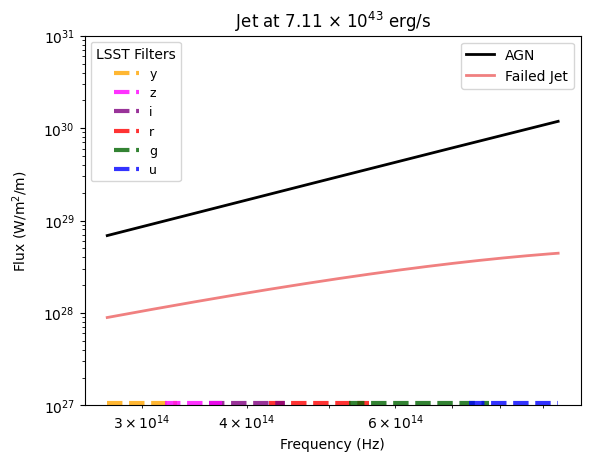

In [ ]:

#jet parameters lum_jet,jet_opening_angle, disk_height, disk_dens, number 
# 7.105091653075504e+43 0.17453292519943295 5287088298781914.0 2.7066864292176647e-06, 400
#jet velocity 18091.99206062451
#1g-1g merger

fig, ax = plt.subplots()

# --- SED curves ---
agn_line, = ax.plot(
    sorted_freq, sorted_SED,
    color='black', linewidth=2, label="AGN"
)

jet_line, = ax.plot(
    sorted_freq,
    planck_total * 2.383575908522985e+31 ,
    color='lightcoral', linewidth=2, label="Failed Jet"
)

#--- Filter bars ---
y_level = 1.05e27

r_bar = ax.hlines(y_level, r_freq.min(), r_freq.max(),
                  color='red', linewidth=3,linestyles = '--', alpha = 0.8, label='r')
g_bar = ax.hlines(y_level, g_freq.min(), g_freq.max(),
                  color='darkgreen', linewidth=3,linestyles = '--', alpha = 0.8, label='g')
i_bar = ax.hlines(y_level, i_freq.min(), i_freq.max(),
                  color='purple', linewidth=3,linestyles = '--', alpha = 0.8, label='i')
u_bar = ax.hlines(y_level, u_freq.min(), u_freq.max(),
                  color='blue', linewidth=3, linestyles = '--', alpha = 0.8,label='u')
y_bar = ax.hlines(y_level, y_freq.min(), y_freq.max(),
                  color='orange', linewidth=3,linestyles = '--', alpha = 0.8, label='y')
z_bar = ax.hlines(y_level, z_freq.min(), z_freq.max(),
                  color='magenta', linewidth=3,linestyles = '--', alpha = 0.8, label='z')

# --- Legends ---
# Top-left: AGN + Jet
legend_main = ax.legend(
    handles=[agn_line, jet_line],
    loc='upper right'
)
ax.add_artist(legend_main)

# Bottom-left: filters
ax.legend(
    handles=[y_bar,z_bar, i_bar, r_bar, g_bar, u_bar],
    loc='upper left',
    title='LSST Filters',
    fontsize=9
)

# --- Axes styling ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title(r"Jet at 7.11 × $10^{43}$ erg/s")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(r"Flux (W/m$^{2}$/m)", labelpad=10)
ax.set_ylim(bottom=1e27, top=1e31)

plt.show()
